# 📚 SEMAINE 1 : Introduction à Python et Machine Learning

**Projet:** Détection précoce DT1 - Cameroun  
**Objectifs:**
- Maîtriser NumPy et Pandas pour manipulation de données
- Créer des visualisations avec Matplotlib
- Comprendre les bases du Machine Learning
- Entraîner un premier modèle simple (Decision Tree)

**Durée estimée:** 10-12 heures

---

## 🔧 Partie 1 : Configuration et Import des Bibliothèques

Nous allons d'abord importer toutes les bibliothèques nécessaires pour ce notebook.

In [1]:
# Import des bibliothèques essentielles
import numpy as np  # Calculs numériques et manipulation de matrices
import pandas as pd  # Manipulation de données tabulaires
import matplotlib.pyplot as plt  # Visualisations graphiques
import seaborn as sns  # Visualisations statistiques élégantes
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Modèle d'arbre de décision
from sklearn.model_selection import train_test_split  # Division train/test
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métriques d'évaluation
import warnings
warnings.filterwarnings('ignore')  # Désactiver les avertissements pour une sortie propre

# Configuration des graphiques pour un meilleur rendu
plt.style.use('seaborn-v0_8-darkgrid')  # Style élégant pour les graphiques
sns.set_palette("husl")  # Palette de couleurs vibrante

print("✅ Toutes les bibliothèques ont été importées avec succès!")
print(f"Version NumPy: {np.__version__}")
print(f"Version Pandas: {pd.__version__}")

✅ Toutes les bibliothèques ont été importées avec succès!
Version NumPy: 1.26.4
Version Pandas: 2.2.2


## 📊 Partie 2 : Introduction à NumPy

NumPy est la bibliothèque fondamentale pour le calcul scientifique en Python. Elle permet de manipuler efficacement des tableaux multidimensionnels.

In [2]:
# === CRÉATION DE TABLEAUX ===

# Tableau 1D (vecteur)
ages = np.array([25, 30, 18, 45, 12, 28, 35])  # Âges de patients
print("Tableau 1D - Âges des patients:")
print(ages)
print(f"Forme: {ages.shape}, Type: {ages.dtype}\n")

# Tableau 2D (matrice)
donnees_patients = np.array([
    [25, 22.5, 5.8],  # Patient 1: âge, IMC, glycémie
    [30, 24.1, 6.2],  # Patient 2
    [18, 19.8, 11.5], # Patient 3
    [45, 28.3, 5.2]   # Patient 4
])
print("Tableau 2D - Données de 4 patients (âge, IMC, glycémie):")
print(donnees_patients)
print(f"Forme: {donnees_patients.shape} = {donnees_patients.shape[0]} patients × {donnees_patients.shape[1]} variables\n")

Tableau 1D - Âges des patients:
[25 30 18 45 12 28 35]
Forme: (7,), Type: int64

Tableau 2D - Données de 4 patients (âge, IMC, glycémie):
[[25.  22.5  5.8]
 [30.  24.1  6.2]
 [18.  19.8 11.5]
 [45.  28.3  5.2]]
Forme: (4, 3) = 4 patients × 3 variables



In [3]:
# === OPÉRATIONS STATISTIQUES ===

# Statistiques sur les âges
print("📈 Statistiques sur les âges:")
print(f"   Moyenne: {ages.mean():.2f} ans")
print(f"   Médiane: {np.median(ages):.2f} ans")
print(f"   Écart-type: {ages.std():.2f} ans")
print(f"   Min: {ages.min()} ans, Max: {ages.max()} ans\n")

# Statistiques par colonne (variable)
print("📊 Statistiques par variable (colonnes):")
colonnes = ['Âge', 'IMC', 'Glycémie']
for i, col in enumerate(colonnes):
    print(f"   {col}: Moyenne = {donnees_patients[:, i].mean():.2f}")

📈 Statistiques sur les âges:
   Moyenne: 27.57 ans
   Médiane: 28.00 ans
   Écart-type: 10.04 ans
   Min: 12 ans, Max: 45 ans

📊 Statistiques par variable (colonnes):
   Âge: Moyenne = 29.50
   IMC: Moyenne = 23.68
   Glycémie: Moyenne = 7.17


In [4]:
# === INDEXATION ET SLICING ===

print("🔍 Indexation et découpage de tableaux:\n")

# Accéder à un élément
print(f"Glycémie du patient 3: {donnees_patients[2, 2]} mmol/L")

# Extraire une colonne (toutes les glycémies)
glycemies = donnees_patients[:, 2]
print(f"Toutes les glycémies: {glycemies}")

# Extraire une ligne (données du patient 1)
patient1 = donnees_patients[0, :]
print(f"Données du patient 1: {patient1}")

# Filtrage conditionnel (patients avec glycémie > 7)
patients_hyperglycemie = donnees_patients[donnees_patients[:, 2] > 7]
print(f"\nPatients avec hyperglycémie (>7 mmol/L):\n{patients_hyperglycemie}")

🔍 Indexation et découpage de tableaux:

Glycémie du patient 3: 11.5 mmol/L
Toutes les glycémies: [ 5.8  6.2 11.5  5.2]
Données du patient 1: [25.  22.5  5.8]

Patients avec hyperglycémie (>7 mmol/L):
[[18.  19.8 11.5]]


### ✏️ Exercice 1 : Manipulation NumPy

**Tâche:** Créez un tableau NumPy contenant les HbA1c de 5 patients : [5.2, 6.8, 11.2, 5.5, 9.1].  
Calculez la moyenne et identifiez les patients avec HbA1c > 6.5% (seuil diabète).

In [5]:
# VOTRE CODE ICI
hba1c = np.array([5.2, 6.8, 11.2, 5.5, 9.1])  # Tableau des HbA1c

# Calculer la moyenne
moyenne_hba1c = hba1c.mean()
print(f"Moyenne HbA1c: {moyenne_hba1c:.2f}%")

# Identifier patients diabétiques (HbA1c > 6.5%)
patients_diabetiques = hba1c > 6.5
print(f"Patients diabétiques: {np.where(patients_diabetiques)[0] + 1}")  # +1 pour indexation humaine
print(f"Valeurs HbA1c diabétiques: {hba1c[patients_diabetiques]}")

Moyenne HbA1c: 7.56%
Patients diabétiques: [2 3 5]
Valeurs HbA1c diabétiques: [ 6.8 11.2  9.1]


## 🗂️ Partie 3 : Introduction à Pandas

Pandas est la bibliothèque de référence pour manipuler des données tabulaires (comme Excel ou CSV).

In [6]:
# === CRÉATION D'UN DATAFRAME ===

# Créer un dictionnaire de données
data = {
    'ID_patient': ['P001', 'P002', 'P003', 'P004', 'P005'],
    'age': [25, 18, 32, 12, 45],
    'sexe': ['F', 'M', 'F', 'M', 'F'],
    'IMC': [22.5, 19.8, 26.1, 17.2, 28.9],
    'glycemie': [5.8, 12.3, 6.1, 14.2, 5.5],
    'HbA1c': [5.4, 11.8, 5.9, 13.2, 5.3],
    'diagnostic': ['Sain', 'DT1', 'Sain', 'DT1', 'Sain']
}

# Convertir en DataFrame
df = pd.DataFrame(data)

print("📋 DataFrame créé avec succès!")
print("\nAperçu des données:")
print(df)

📋 DataFrame créé avec succès!

Aperçu des données:
  ID_patient  age sexe   IMC  glycemie  HbA1c diagnostic
0       P001   25    F  22.5       5.8    5.4       Sain
1       P002   18    M  19.8      12.3   11.8        DT1
2       P003   32    F  26.1       6.1    5.9       Sain
3       P004   12    M  17.2      14.2   13.2        DT1
4       P005   45    F  28.9       5.5    5.3       Sain


In [7]:
# === EXPLORATION DU DATAFRAME ===

print("🔍 Informations sur le DataFrame:\n")

# Forme du DataFrame
print(f"Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")

# Types de données
print("\nTypes de colonnes:")
print(df.dtypes)

# Statistiques descriptives
print("\nStatistiques descriptives:")
print(df.describe())

# Valeurs manquantes
print("\nValeurs manquantes par colonne:")
print(df.isnull().sum())

🔍 Informations sur le DataFrame:

Dimensions: 5 lignes × 7 colonnes

Types de colonnes:
ID_patient     object
age             int64
sexe           object
IMC           float64
glycemie      float64
HbA1c         float64
diagnostic     object
dtype: object

Statistiques descriptives:
             age        IMC   glycemie      HbA1c
count   5.000000   5.000000   5.000000   5.000000
mean   26.400000  22.900000   8.780000   8.320000
std    12.817956   4.703722   4.140894   3.854478
min    12.000000  17.200000   5.500000   5.300000
25%    18.000000  19.800000   5.800000   5.400000
50%    25.000000  22.500000   6.100000   5.900000
75%    32.000000  26.100000  12.300000  11.800000
max    45.000000  28.900000  14.200000  13.200000

Valeurs manquantes par colonne:
ID_patient    0
age           0
sexe          0
IMC           0
glycemie      0
HbA1c         0
diagnostic    0
dtype: int64


In [8]:
# === SÉLECTION ET FILTRAGE ===

print("🎯 Sélection et filtrage de données:\n")

# Sélectionner une colonne
ages_series = df['age']
print(f"Âges: {ages_series.tolist()}")

# Sélectionner plusieurs colonnes
subset = df[['ID_patient', 'age', 'diagnostic']]
print("\nSous-ensemble (ID, âge, diagnostic):")
print(subset)

# Filtrer les patients DT1
patients_dt1 = df[df['diagnostic'] == 'DT1']
print("\n🔴 Patients avec DT1:")
print(patients_dt1[['ID_patient', 'age', 'glycemie', 'HbA1c']])

🎯 Sélection et filtrage de données:

Âges: [25, 18, 32, 12, 45]

Sous-ensemble (ID, âge, diagnostic):
  ID_patient  age diagnostic
0       P001   25       Sain
1       P002   18        DT1
2       P003   32       Sain
3       P004   12        DT1
4       P005   45       Sain

🔴 Patients avec DT1:
  ID_patient  age  glycemie  HbA1c
1       P002   18      12.3   11.8
3       P004   12      14.2   13.2


In [9]:
# === AGRÉGATIONS PAR GROUPE ===

print("📊 Statistiques par groupe de diagnostic:\n")

# Moyennes par groupe
moyennes_par_diagnostic = df.groupby('diagnostic')[['age', 'IMC', 'glycemie', 'HbA1c']].mean()
print(moyennes_par_diagnostic)

# Comptage par sexe
print("\nRépartition par sexe:")
print(df['sexe'].value_counts())

📊 Statistiques par groupe de diagnostic:

             age        IMC  glycemie      HbA1c
diagnostic                                      
DT1         15.0  18.500000     13.25  12.500000
Sain        34.0  25.833333      5.80   5.533333

Répartition par sexe:
sexe
F    3
M    2
Name: count, dtype: int64


### ✏️ Exercice 2 : Manipulation Pandas

**Tâche:** Ajoutez une nouvelle colonne `risque` au DataFrame :  
- "Élevé" si glycémie > 10 ET HbA1c > 8  
- "Moyen" si glycémie > 7 OU HbA1c > 6.5  
- "Faible" sinon

In [10]:
# VOTRE CODE ICI

# Fonction pour déterminer le niveau de risque
def evaluer_risque(row):
    if row['glycemie'] > 10 and row['HbA1c'] > 8:
        return 'Élevé'
    elif row['glycemie'] > 7 or row['HbA1c'] > 6.5:
        return 'Moyen'
    else:
        return 'Faible'

# Appliquer la fonction à chaque ligne
df['risque'] = df.apply(evaluer_risque, axis=1)

print("🎯 Colonne 'risque' ajoutée:")
print(df[['ID_patient', 'glycemie', 'HbA1c', 'risque']])

# Comptage par niveau de risque
print("\nDistribution des risques:")
print(df['risque'].value_counts())

🎯 Colonne 'risque' ajoutée:
  ID_patient  glycemie  HbA1c  risque
0       P001       5.8    5.4  Faible
1       P002      12.3   11.8   Élevé
2       P003       6.1    5.9  Faible
3       P004      14.2   13.2   Élevé
4       P005       5.5    5.3  Faible

Distribution des risques:
risque
Faible    3
Élevé     2
Name: count, dtype: int64


## 📈 Partie 4 : Visualisations avec Matplotlib

Les visualisations sont essentielles pour comprendre les données et communiquer les résultats.

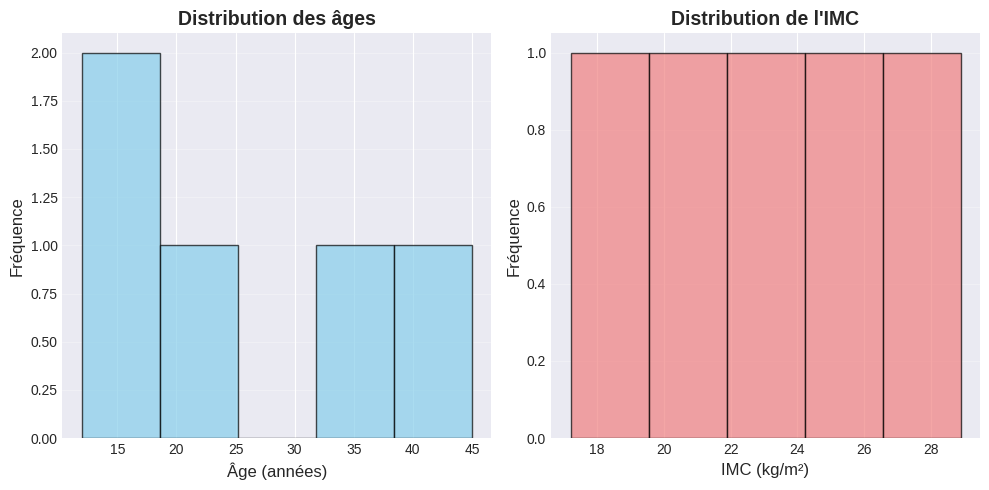

In [11]:
# === GRAPHIQUE 1 : HISTOGRAMME ===

plt.figure(figsize=(10, 5))

# Sous-graphique 1 : Distribution des âges
plt.subplot(1, 2, 1)  # 1 ligne, 2 colonnes, position 1
plt.hist(df['age'], bins=5, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Âge (années)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des âges', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Sous-graphique 2 : Distribution de l'IMC
plt.subplot(1, 2, 2)  # 1 ligne, 2 colonnes, position 2
plt.hist(df['IMC'], bins=5, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('IMC (kg/m²)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution de l\'IMC', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()  # Ajuster l'espacement entre les graphiques
plt.show()

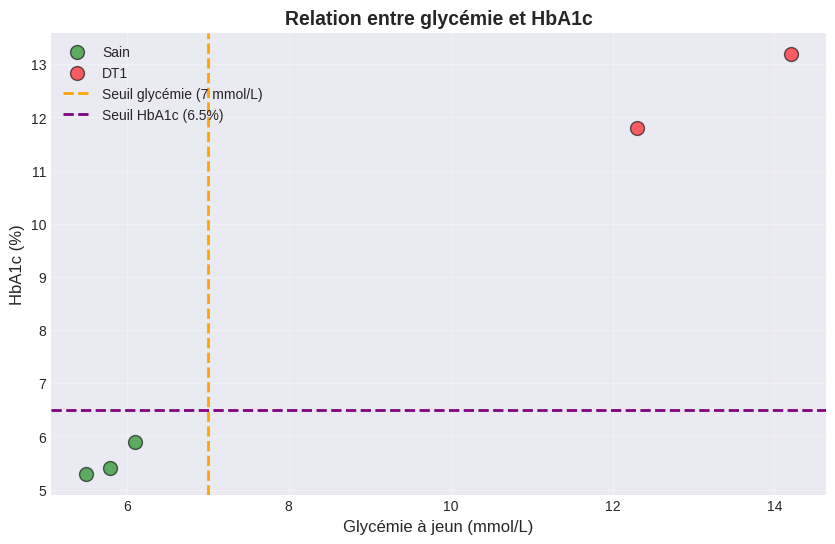

In [12]:
# === GRAPHIQUE 2 : SCATTER PLOT (NUAGE DE POINTS) ===

plt.figure(figsize=(10, 6))

# Séparer les données par diagnostic
sains = df[df['diagnostic'] == 'Sain']
dt1 = df[df['diagnostic'] == 'DT1']

# Tracer les points avec des couleurs différentes
plt.scatter(sains['glycemie'], sains['HbA1c'], 
            color='green', s=100, alpha=0.6, label='Sain', edgecolors='black')
plt.scatter(dt1['glycemie'], dt1['HbA1c'], 
            color='red', s=100, alpha=0.6, label='DT1', edgecolors='black')

# Lignes de seuil
plt.axvline(x=7, color='orange', linestyle='--', linewidth=2, label='Seuil glycémie (7 mmol/L)')
plt.axhline(y=6.5, color='purple', linestyle='--', linewidth=2, label='Seuil HbA1c (6.5%)')

plt.xlabel('Glycémie à jeun (mmol/L)', fontsize=12)
plt.ylabel('HbA1c (%)', fontsize=12)
plt.title('Relation entre glycémie et HbA1c', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

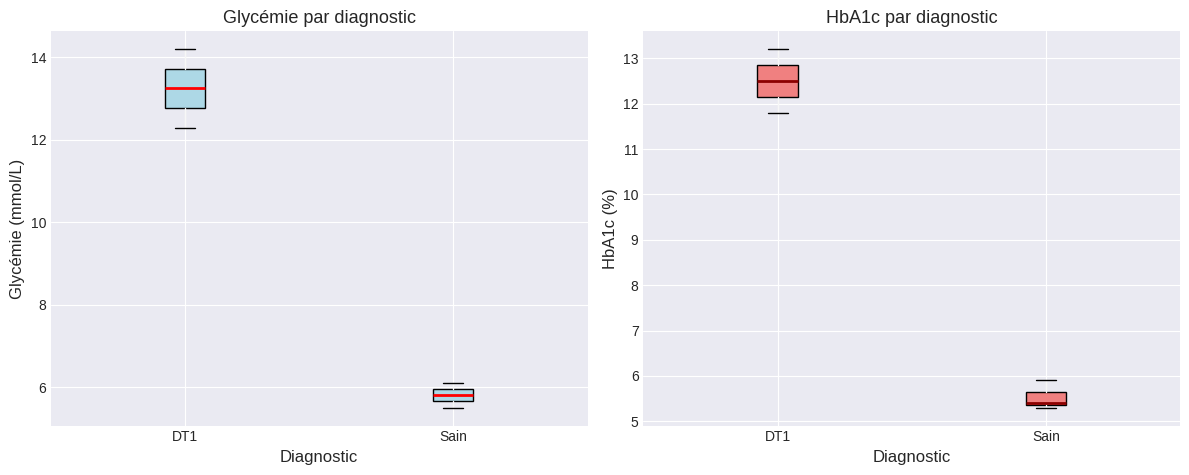

In [13]:
# === GRAPHIQUE 3 : BOXPLOT (BOÎTE À MOUSTACHES) ===

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot de la glycémie par diagnostic
df.boxplot(column='glycemie', by='diagnostic', ax=axes[0], 
           patch_artist=True, 
           boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_xlabel('Diagnostic', fontsize=12)
axes[0].set_ylabel('Glycémie (mmol/L)', fontsize=12)
axes[0].set_title('Glycémie par diagnostic', fontsize=13)
plt.sca(axes[0])
plt.xticks([1, 2], ['DT1', 'Sain'])

# Boxplot de l'HbA1c par diagnostic
df.boxplot(column='HbA1c', by='diagnostic', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='lightcoral', color='black'),
           medianprops=dict(color='darkred', linewidth=2))
axes[1].set_xlabel('Diagnostic', fontsize=12)
axes[1].set_ylabel('HbA1c (%)', fontsize=12)
axes[1].set_title('HbA1c par diagnostic', fontsize=13)
plt.sca(axes[1])
plt.xticks([1, 2], ['DT1', 'Sain'])

plt.suptitle('')  # Supprimer le titre automatique
plt.tight_layout()
plt.show()

### ✏️ Exercice 3 : Créer une visualisation

**Tâche:** Créez un graphique en barres montrant la moyenne de l'IMC par sexe.

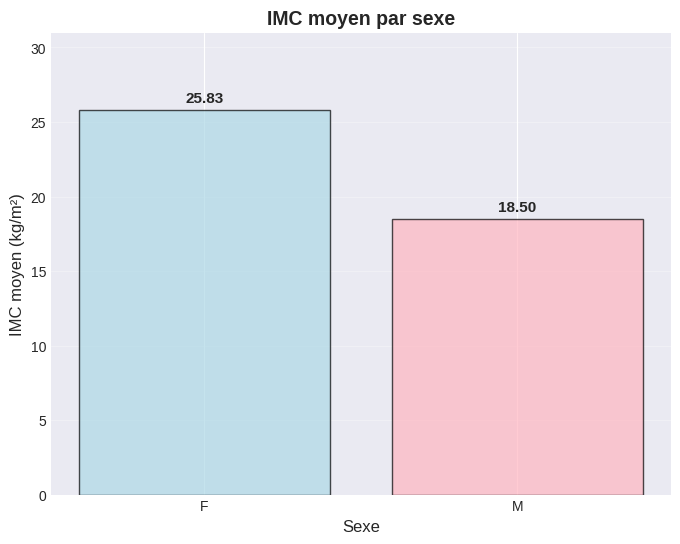

In [14]:
# VOTRE CODE ICI

# Calculer la moyenne de l'IMC par sexe
imc_par_sexe = df.groupby('sexe')['IMC'].mean()

# Créer le graphique en barres
plt.figure(figsize=(8, 6))
plt.bar(imc_par_sexe.index, imc_par_sexe.values, 
        color=['lightblue', 'lightpink'], edgecolor='black', alpha=0.7)
plt.xlabel('Sexe', fontsize=12)
plt.ylabel('IMC moyen (kg/m²)', fontsize=12)
plt.title('IMC moyen par sexe', fontsize=14, fontweight='bold')
plt.ylim(0, max(imc_par_sexe.values) * 1.2)  # Ajouter de l'espace au-dessus

# Ajouter les valeurs au-dessus des barres
for i, v in enumerate(imc_par_sexe.values):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 🤖 Partie 5 : Premier Modèle de Machine Learning

Nous allons maintenant entraîner un **arbre de décision** pour prédire le diagnostic DT1.

### Étapes du Machine Learning:
1. **Préparation des données** (X = features, y = target)
2. **Division train/test** (80% entraînement, 20% test)
3. **Entraînement du modèle**
4. **Prédiction sur les données de test**
5. **Évaluation des performances**

In [15]:
# === CHARGEMENT DU DATASET COMPLET ===

# Charger le dataset synthétique généré précédemment
df_full = pd.read_csv('../2_DONNEES/raw/dataset_dt1_cameroun_synthetic.csv')

print("📂 Dataset chargé:")
print(f"   {df_full.shape[0]} patients, {df_full.shape[1]} colonnes")
print("\nAperçu des 5 premières lignes:")
print(df_full.head())

# Vérifier la distribution du diagnostic
print("\nDistribution des diagnostics:")
print(df_full['diagnostic'].value_counts())
print(f"Proportion DT1: {df_full['diagnostic'].mean()*100:.1f}%")

📂 Dataset chargé:
   1000 patients, 12 colonnes

Aperçu des 5 premières lignes:
  ID_patient  age sexe   region    IMC  glycemie_jeun  HbA1c  \
0    PAT0522   41    F  Yaoundé  26.53           4.33   5.02   
1    PAT0738   46    F  Yaoundé  28.21           4.77   5.90   
2    PAT0741   12    M   Douala  20.63           5.55   5.18   
3    PAT0661   28    F   Garoua  30.05           6.11   5.16   
4    PAT0412   21    M  Yaoundé  31.74           3.73   5.88   

   antecedents_familiaux  ANP32A_IT1  ESCO2  NBPF1  diagnostic  
0                      0       1.048  1.000  1.047           0  
1                      0       2.327  2.247  3.053           0  
2                      0       0.727  1.000  1.097           0  
3                      0       0.972  1.271  1.165           0  
4                      0       0.652  1.424  1.999           0  

Distribution des diagnostics:
diagnostic
0    750
1    250
Name: count, dtype: int64
Proportion DT1: 25.0%


In [16]:
# === ÉTAPE 1 : PRÉPARATION DES DONNÉES ===

# Sélectionner les features (variables prédictives)
features = ['age', 'IMC', 'glycemie_jeun', 'HbA1c', 'ANP32A_IT1', 'ESCO2', 'NBPF1']
X = df_full[features]  # Matrice des features
y = df_full['diagnostic']  # Variable cible (0 = Sain, 1 = DT1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("📊 Préparation des données:")
print(f"   Features (X): {X.shape[0]} échantillons × {X.shape[1]} variables")
print(f"   Target (y): {y.shape[0]} labels")
print(f"\nVariables utilisées: {features}")

📊 Préparation des données:
   Features (X): 1000 échantillons × 7 variables
   Target (y): 1000 labels

Variables utilisées: ['age', 'IMC', 'glycemie_jeun', 'HbA1c', 'ANP32A_IT1', 'ESCO2', 'NBPF1']


In [24]:
# === ÉTAPE 3 : ENTRAÎNEMENT DU MODÈLE ===

# Créer le modèle d'arbre de décision
modele = DecisionTreeClassifier(
    max_depth=4,          # Profondeur maximale de l'arbre (éviter overfitting)
    min_samples_split=20, # Minimum d'échantillons pour diviser un nœud
    random_state=42       # Reproductibilité
)

# Entraîner le modèle sur les données d'entraînement
print("🤖 Entraînement du modèle en cours...")
modele.fit(X_train, y_train)
print("✅ Modèle entraîné avec succès!")

# Afficher quelques informations sur l'arbre
print(f"\nProfondeur de l'arbre: {modele.get_depth()}")
print(f"Nombre de feuilles: {modele.get_n_leaves()}")

🤖 Entraînement du modèle en cours...
✅ Modèle entraîné avec succès!

Profondeur de l'arbre: 4
Nombre de feuilles: 6


In [18]:
# === ÉTAPE 4 : PRÉDICTIONS ===

# Faire des prédictions sur l'ensemble de test
y_pred = modele.predict(X_test)

print("🔮 Prédictions effectuées sur l'ensemble de test")
print(f"\nExemple des 10 premières prédictions:")
print(f"   Vraies valeurs: {y_test.iloc[:10].values}")
print(f"   Prédictions:    {y_pred[:10]}")

# Comparer visuellement
comparaison = pd.DataFrame({
    'Vrai': y_test.iloc[:10].values,
    'Prédit': y_pred[:10],
    'Correct': y_test.iloc[:10].values == y_pred[:10]
})
print("\nComparaison détaillée (10 premiers):")
print(comparaison)

🔮 Prédictions effectuées sur l'ensemble de test

Exemple des 10 premières prédictions:
   Vraies valeurs: [0 1 0 1 0 0 1 1 0 1]
   Prédictions:    [0 1 0 1 0 0 1 1 0 1]

Comparaison détaillée (10 premiers):
   Vrai  Prédit  Correct
0     0       0     True
1     1       1     True
2     0       0     True
3     1       1     True
4     0       0     True
5     0       0     True
6     1       1     True
7     1       1     True
8     0       0     True
9     1       1     True


In [19]:
# === ÉTAPE 5 : ÉVALUATION DES PERFORMANCES ===

# Calculer l'accuracy (exactitude)
accuracy = accuracy_score(y_test, y_pred)
print(f"📊 ACCURACY: {accuracy*100:.2f}%")
print(f"   Le modèle prédit correctement {accuracy*100:.1f}% des cas\n")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("📈 MATRICE DE CONFUSION:")
print(cm)
print("\nInterprétation:")
print(f"   Vrais Négatifs (Sain prédit Sain): {cm[0,0]}")
print(f"   Faux Positifs (Sain prédit DT1): {cm[0,1]}")
print(f"   Faux Négatifs (DT1 prédit Sain): {cm[1,0]}")
print(f"   Vrais Positifs (DT1 prédit DT1): {cm[1,1]}")

# Rapport de classification détaillé
print("\n📋 RAPPORT DE CLASSIFICATION:")
print(classification_report(y_test, y_pred, target_names=['Sain', 'DT1']))

📊 ACCURACY: 99.50%
   Le modèle prédit correctement 99.5% des cas

📈 MATRICE DE CONFUSION:
[[141   1]
 [  0  58]]

Interprétation:
   Vrais Négatifs (Sain prédit Sain): 141
   Faux Positifs (Sain prédit DT1): 1
   Faux Négatifs (DT1 prédit Sain): 0
   Vrais Positifs (DT1 prédit DT1): 58

📋 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

        Sain       1.00      0.99      1.00       142
         DT1       0.98      1.00      0.99        58

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



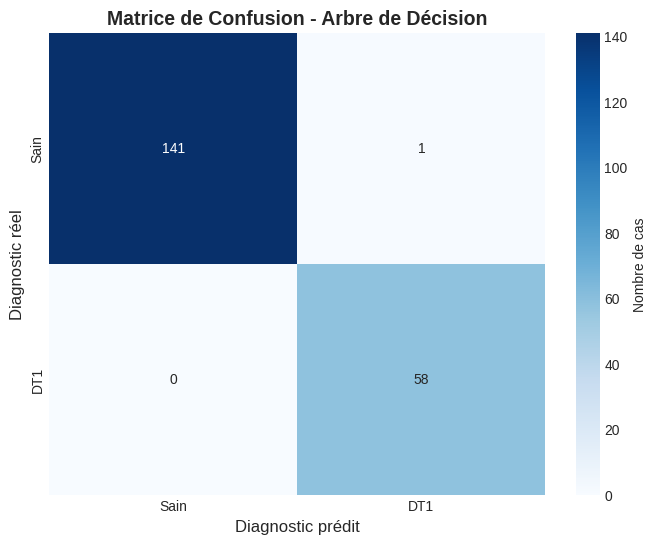

In [20]:
# === VISUALISATION DE LA MATRICE DE CONFUSION ===

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sain', 'DT1'], 
            yticklabels=['Sain', 'DT1'],
            cbar_kws={'label': 'Nombre de cas'})
plt.xlabel('Diagnostic prédit', fontsize=12)
plt.ylabel('Diagnostic réel', fontsize=12)
plt.title('Matrice de Confusion - Arbre de Décision', fontsize=14, fontweight='bold')
plt.show()

🔍 Importance des variables:
        Variable  Importance
2  glycemie_jeun    0.869524
3          HbA1c    0.120172
4     ANP32A_IT1    0.010304
0            age    0.000000
1            IMC    0.000000
5          ESCO2    0.000000
6          NBPF1    0.000000


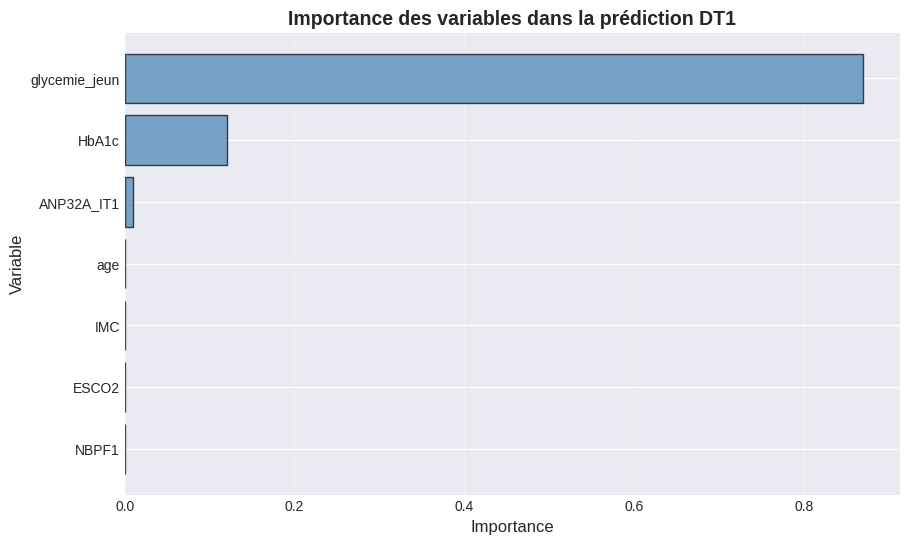

In [21]:
# === IMPORTANCE DES VARIABLES ===

# Extraire l'importance de chaque feature
importances = modele.feature_importances_
feature_importance_df = pd.DataFrame({
    'Variable': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("🔍 Importance des variables:")
print(feature_importance_df)

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Variable'], feature_importance_df['Importance'], 
         color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Variable', fontsize=12)
plt.title('Importance des variables dans la prédiction DT1', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Inverser pour avoir la plus importante en haut
plt.grid(axis='x', alpha=0.3)
plt.show()

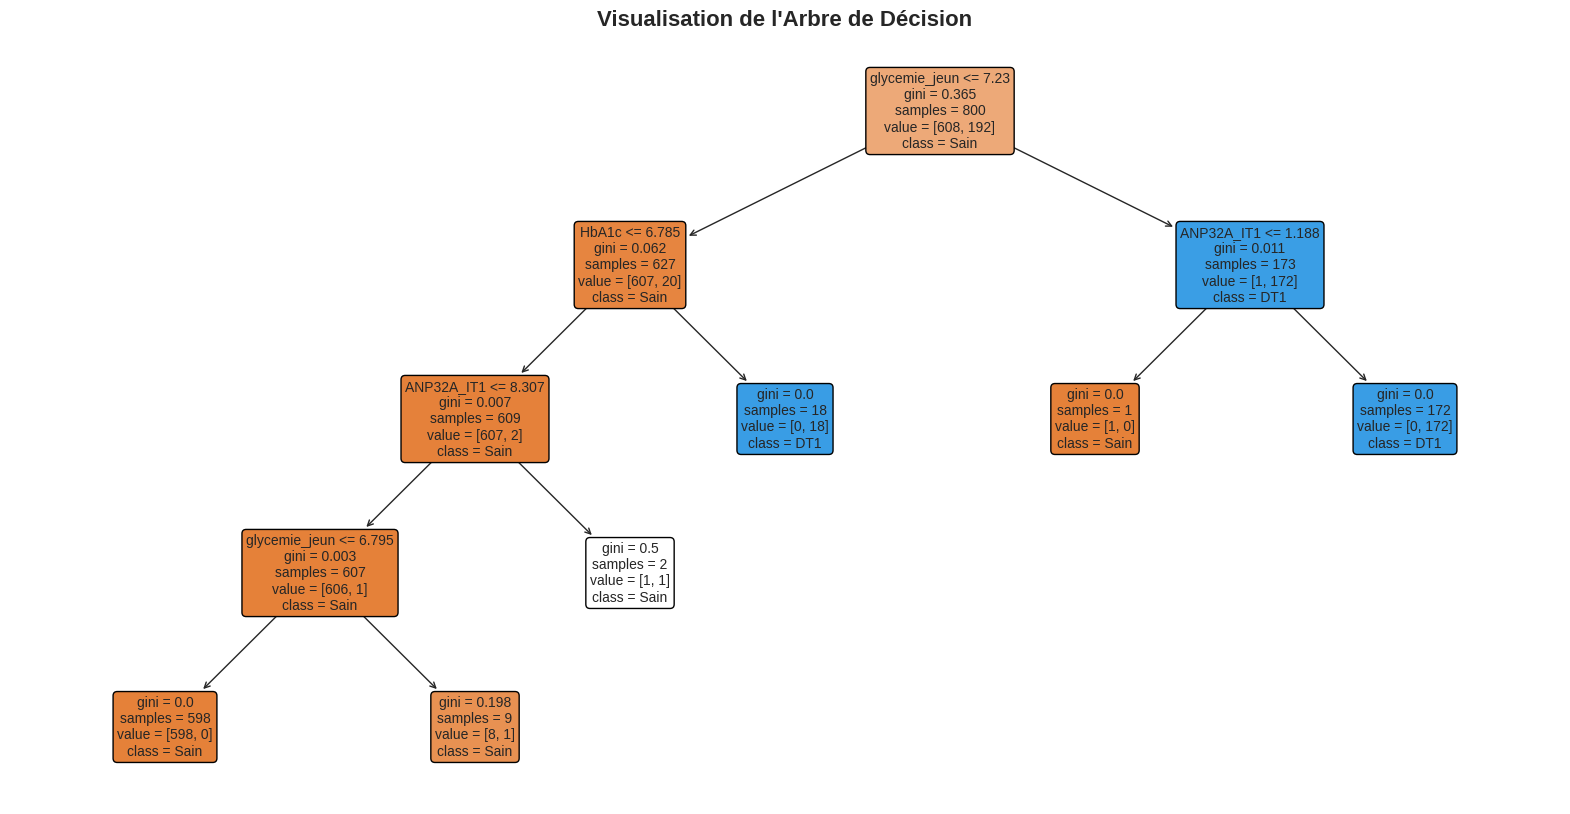


💡 Interprétation de l'arbre:
   - Chaque nœud montre une condition de séparation
   - 'samples' = nombre d'échantillons dans ce nœud
   - 'value' = [nombre de Sains, nombre de DT1]
   - Les couleurs indiquent la classe majoritaire (orange = DT1, bleu = Sain)


In [22]:
# === VISUALISATION DE L'ARBRE DE DÉCISION ===

plt.figure(figsize=(20, 10))
plot_tree(modele, 
          feature_names=features,
          class_names=['Sain', 'DT1'],
          filled=True,           # Colorer les nœuds selon la classe majoritaire
          rounded=True,          # Arrondir les boîtes
          fontsize=10)
plt.title('Visualisation de l\'Arbre de Décision', fontsize=16, fontweight='bold')
plt.show()

print("\n💡 Interprétation de l'arbre:")
print("   - Chaque nœud montre une condition de séparation")
print("   - 'samples' = nombre d'échantillons dans ce nœud")
print("   - 'value' = [nombre de Sains, nombre de DT1]")
print("   - Les couleurs indiquent la classe majoritaire (orange = DT1, bleu = Sain)")

## 🎯 Auto-évaluation

### Questions de compréhension:

1. **Quelle est la différence entre NumPy et Pandas?**
   - NumPy: manipulation de tableaux numériques (matrices, vecteurs)
   - Pandas: manipulation de données tabulaires (DataFrame avec colonnes nommées)

2. **Pourquoi divise-t-on les données en train/test?**
   - Train: pour apprendre les patterns (entraîner le modèle)
   - Test: pour évaluer les performances sur des données non vues (éviter l'overfitting)

3. **Qu'est-ce qu'un Faux Négatif et pourquoi est-ce grave en médecine?**
   - Faux Négatif: patient DT1 prédit comme Sain
   - Grave car le patient ne sera pas traité et risque des complications

4. **Quelle variable est la plus importante selon votre modèle?**
   - Voir le graphique d'importance ci-dessus (généralement glycémie ou HbA1c)

### Exercice récapitulatif:

Entraînez un nouvel arbre de décision avec `max_depth=2` et comparez l'accuracy avec le modèle précédent (`max_depth=4`). Lequel est meilleur?

In [23]:
# EXERCICE RÉCAPITULATIF - VOTRE CODE ICI

# Créer un modèle avec profondeur 2
modele_simple = DecisionTreeClassifier(max_depth=2, random_state=42)
modele_simple.fit(X_train, y_train)

# Prédictions
y_pred_simple = modele_simple.predict(X_test)

# Évaluation
accuracy_simple = accuracy_score(y_test, y_pred_simple)

print("📊 Comparaison des modèles:\n")
print(f"   Modèle profondeur=4: Accuracy = {accuracy*100:.2f}%")
print(f"   Modèle profondeur=2: Accuracy = {accuracy_simple*100:.2f}%")
print(f"\n   Différence: {(accuracy - accuracy_simple)*100:.2f} points de %")

if accuracy > accuracy_simple:
    print("\n✅ Le modèle plus complexe (profondeur=4) performe mieux")
else:
    print("\n⚠️ Le modèle simple (profondeur=2) performe mieux (moins d'overfitting?)")

📊 Comparaison des modèles:

   Modèle profondeur=4: Accuracy = 99.50%
   Modèle profondeur=2: Accuracy = 99.50%

   Différence: 0.00 points de %

⚠️ Le modèle simple (profondeur=2) performe mieux (moins d'overfitting?)


## 🎉 Félicitations!

Vous avez terminé la Semaine 1 avec succès! Vous maîtrisez maintenant:

✅ Manipulation de données avec NumPy et Pandas  
✅ Création de visualisations avec Matplotlib  
✅ Entraînement d'un modèle de Machine Learning  
✅ Évaluation des performances (accuracy, matrice de confusion)  

### 📚 Pour aller plus loin:
- Testez d'autres hyperparamètres (min_samples_split, min_samples_leaf)
- Essayez d'autres features (antécédents_familiaux, région)
- Explorez d'autres types de visualisations (pairplot, heatmap de corrélations)

### 📅 Prochaine étape:
**Semaine 2:** Exploration approfondie des données (analyse statistique, corrélations, distribution des biomarqueurs)

---

*Notebook créé pour le projet DT1 Cameroun - Master 2 Biophysique - 2025*